Касьяненко Вера Михайловна 368283

In [ ]:
#@title Установка и импорты
!pip install neurokit2 statsmodels

In [ ]:
import re, gdown, pandas as pd, numpy as np

FILE_LINK = "https://drive.google.com/file/d/1PaSJjggQ4Jftz4goeJEKA463bU26oQZo/view?usp=sharing"
file_id = re.search(r"/d/([^/]+)/", FILE_LINK).group(1)
gdown.download(id=file_id, output="data.csv", quiet=True)

df = pd.read_csv("data.csv", sep=";", header=None, names=["timestamp", "value"])

print(df.head(3))

fs = len(df) / (df["timestamp"].iloc[-1] - df["timestamp"].iloc[0])
print(f"fs ≈ {fs:.2f} Гц")

   timestamp     value
0  16.867664  3.156863
1  16.867664  3.000000
2  16.867664  2.862745
fs ≈ 326.08 Гц


Сигнал + RR пики

In [ ]:
import neurokit2 as nk
import numpy as np

sig = df["value"].to_numpy()
sig_clean = nk.ecg_clean(sig, sampling_rate=fs)
_, info = nk.ecg_peaks(sig_clean, sampling_rate=fs)
peaks = np.asarray(info["ECG_R_Peaks"], dtype=int)

# КАК В ОТЧЁТЕ-2: RR по меткам времени файла
t = df["timestamp"].to_numpy()
rr = np.diff(t[peaks]) # секунды
rr = rr[(rr >= 0.3) & (rr <= 2.0)] # простая очистка

print(f"пиков: {len(peaks)}, RR: {len(rr)}, HR≈{60/rr.mean():.1f}")

пиков: 415, RR: 414, HR≈80.3


ЭКГ и R-пики (увеличенный участок)

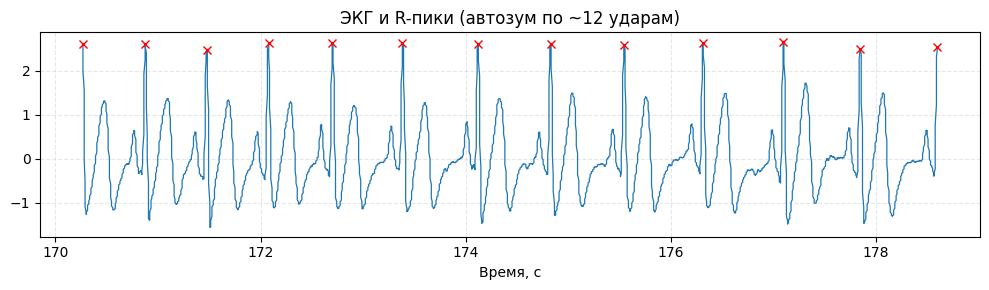

In [ ]:
# ЭКГ и R-пики — автозум по ~12 соседним ударам
import numpy as np
import matplotlib.pyplot as plt

k = 12
i = len(peaks) // 2
if len(peaks) > k + 1:
    a = peaks[max(0, i - k // 2)]
    b = peaks[min(len(peaks) - 1, i + k // 2)]
else:
    a, b = peaks[0], peaks[-1]

sl = slice(a, b)
pk = peaks[(peaks >= a) & (peaks <= b)]

plt.figure(figsize=(10, 3))
plt.plot(t[sl], sig_clean[sl], lw=0.9)
plt.plot(t[pk], sig_clean[pk], "rx", ms=6)
plt.title("ЭКГ и R-пики (автозум по ~12 ударам)")
plt.xlabel("Время, с"); plt.grid(True, ls="--", alpha=.3)
plt.tight_layout(); plt.show()

Кардиоинтервалограмма

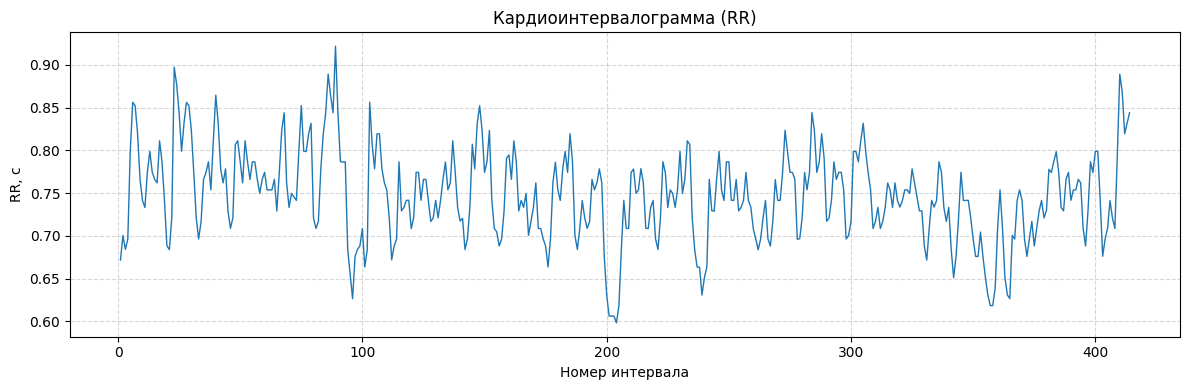

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(np.arange(1, len(rr)+1), rr, lw=1)
plt.title("Кардиоинтервалограмма (RR)")
plt.xlabel("Номер интервала"); plt.ylabel("RR, с")
plt.grid(True, ls="--", alpha=.5)
plt.tight_layout(); plt.show()

Метрики ВРС (HR, Mean RR, SDNN, CV, RMSSD)

In [ ]:
import numpy as np

mean_rr = rr.mean()
hr = 60 / mean_rr
sdnn = rr.std(ddof=1)
cv = sdnn / mean_rr * 100
rmssd = np.sqrt(np.mean(np.diff(rr)**2))

print(f"Средний RR: {mean_rr*1000:.1f} мс")
print(f"ЧСС (HR): {hr:.1f} уд/мин")
print(f"SDNN: {sdnn*1000:.1f} мс")
print(f"CV: {cv:.2f} %")
print(f"RMSSD: {rmssd*1000:.1f} мс")

Средний RR: 747.5 мс
ЧСС (HR): 80.3 уд/мин
SDNN: 53.2 мс
CV: 7.12 %
RMSSD: 36.9 мс


ЧСС 80 уд/мин при среднем RR ~748 мс — верхняя граница нормы для покоя, что может отражать лёгкое преобладание симпатического тонуса.
SDNN 53 мс, CV 7.1% и RMSSD 36.9 мс указывают на умеренную вариабельность с сохранённым парасимпатическим вкладом; профиль ближе к нормотонии. В целом — синусовый ритм без признаков выраженной аритмии (при условии корректной детекции и ≥5-мин записи).

Автокоррелограмма (statsmodels) с безопасным числом лагов

Корреляция (лаг 1): 0.76 (n=414, lags=30)


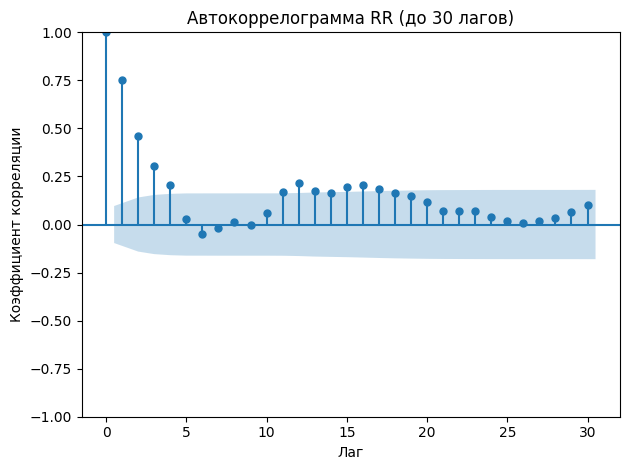

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

rr = rr[np.isfinite(rr)]
n = len(rr)
if n < 3:
    print(f"АКФ: слишком мало точек (n={n})")
else:
    lags = min(30, n - 2)
    rho1 = np.corrcoef(rr[:-1], rr[1:])[0, 1]
    print(f"Корреляция (лаг 1): {rho1:.2f} (n={n}, lags={lags})")
    plot_acf(rr, lags=lags, alpha=0.05, title=f"Автокоррелограмма RR (до {lags} лагов)")
    plt.xlabel("Лаг"); plt.ylabel("Коэффициент корреляции")
    plt.tight_layout(); plt.show()

Корреляционная ритмограмма (Пуанкаре)

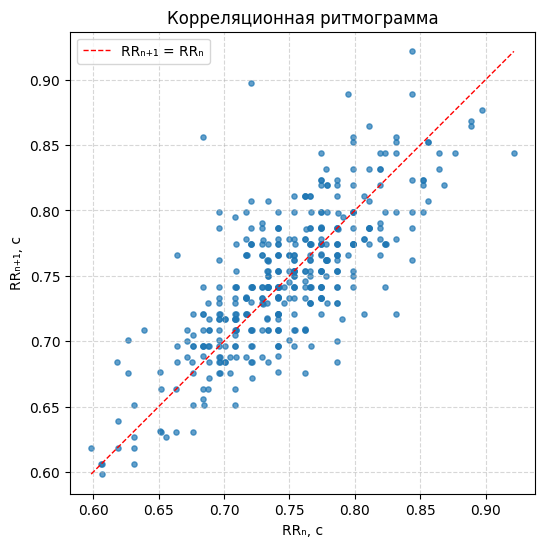

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(rr[:-1], rr[1:], s=14, alpha=.7)
m, M = rr.min(), rr.max()
plt.plot([m, M], [m, M], 'r--', lw=1, label='RRₙ₊₁ = RRₙ')
plt.xlabel("RRₙ, с"); plt.ylabel("RRₙ₊₁, с")
plt.title("Корреляционная ритмограмма")
plt.axis('equal'); plt.grid(True, ls="--", alpha=.5); plt.legend(); plt.show()

Облако точек вытянуто вдоль диагонали y=x, плотное, без «островков» и удалённых выбросов это характерно для регулярного синусового ритма. Разброс умеренный, признаков типичных для аритмий (кластеры при экстрасистолии, «хаос» при ФП) не наблюдается; для окончательного исключения редких эпизодов нужна более длительная запись.

Скаттерограмма RR (RRₙ₊₁ vs RRₙ)

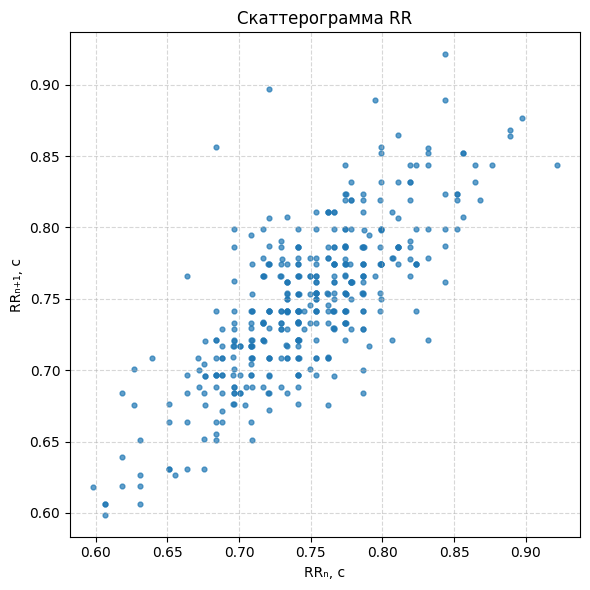

In [ ]:
x, y = rr[:-1], rr[1:]
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=12, alpha=.7)
plt.xlabel("RRₙ, c"); plt.ylabel("RRₙ₊₁, c")
plt.title("Скаттерограмма RR")
plt.grid(True, ls="--", alpha=.5); plt.axis("equal"); plt.tight_layout(); plt.show()

Скаттерограмма показывает плотное облако, вытянутое вдоль диагонали RRₙ₊₁≈RRₙ, без отдельных кластеров и удалённых выбросов — признак устойчивого синусового ритма. Ширина облака умеренная (основная плотность ~0.70–0.80 c), что соответствует физиологической вариабельности; характерных паттернов аритмии (вертикальные/горизонтальные «полосы», разрозненные группы) не видно.

Индекс напряжения по Баевскому (ИН) на основе RR (в секундах)

In [ ]:
bin_w = 0.05
bins  = np.arange(rr.min()-bin_w/2, rr.max()+bin_w, bin_w)
hist, edges = np.histogram(rr, bins=bins)
k = np.argmax(hist)

Mo = 0.5 * (edges[k] + edges[k+1])
AMo = hist[k] / len(rr) * 100
MxDMn = rr.max() - rr.min()
IN = AMo / (2 * Mo * MxDMn)

zone = "ваготония" if IN < 30 else ("нормотония" if IN <= 90 else "симпатикотония")
print(f"Mo={Mo*1000:.1f} мс, AMo={AMo:.1f} %, MxDMn={MxDMn*1000:.1f} мс")
print(f"ИН Баевского = {IN:.1f} усл. ед. → {zone}")

Mo=748.3 мс, AMo=33.3 %, MxDMn=323.3 мс
ИН Баевского = 68.9 усл. ед. → нормотония


ИН Баевского **68.9 усл. ед.** попадает в диапазон **нормотонии (30–90)** регуляция ритма сбалансирована, признаков выражённого напряжения или симпатикотонического сдвига нет.
AMo ≈33% при достаточно широком размахе **MxDMn ≈323 мс** указывает на сохранённую вариабельность и умеренную «централизацию» ритма, соответствующую покою.


Исследование ЭКГ в NeuroKit2 (HRV: time/freq/nonlinear)

,"MeanNN, мс","MeanHR, уд/мин","SDNN, мс","RMSSD, мс","pNN50, %","CVNN, %","VLF, мс²","LF, мс²","HF, мс²",LF/HF,"SD1, мс","SD2, мс"
0,747.48,NaN,53.14,37.13,15.46,0.07,0.01,0.04,0.01,2.93,26.28,70.25


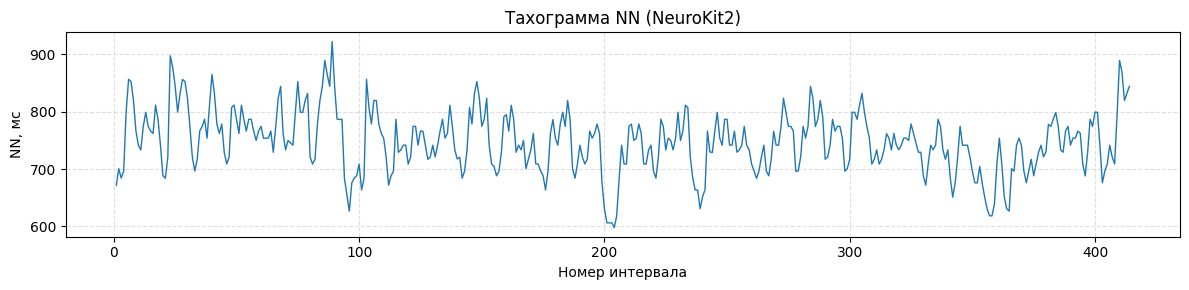

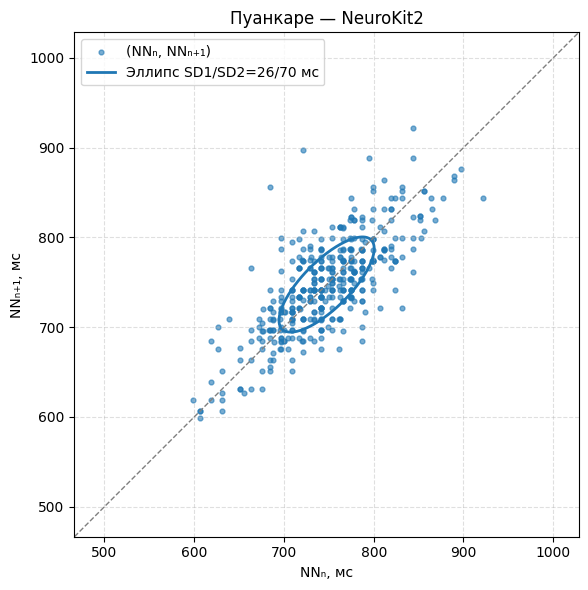

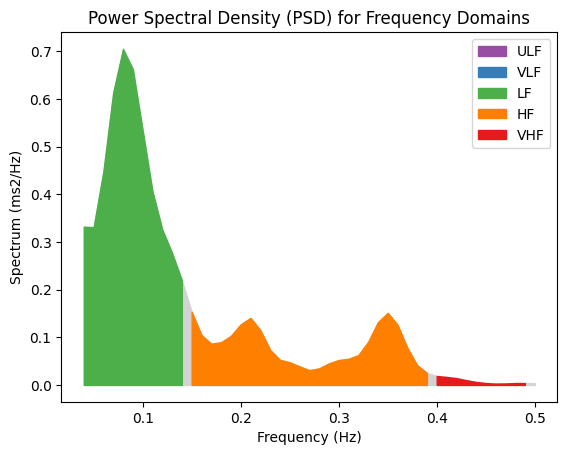

In [ ]:
import neurokit2 as nk
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

rpeaks = {"ECG_R_Peaks": peaks}

# 1) Метрики
time_df = nk.hrv_time(rpeaks, sampling_rate=fs, show=False)
freq_df = nk.hrv_frequency(rpeaks, sampling_rate=fs, psd_method="welch", show=False)
nl_df = nk.hrv_nonlinear(rpeaks, sampling_rate=fs, show=False)

grab = lambda d, k: float(d[k].iloc[0]) if k in d else np.nan
summary = pd.DataFrame({
    "MeanNN, мс": [grab(time_df, "HRV_MeanNN")],
    "MeanHR, уд/мин": [grab(time_df, "HRV_MeanHR")],
    "SDNN, мс": [grab(time_df, "HRV_SDNN")],
    "RMSSD, мс": [grab(time_df, "HRV_RMSSD")],
    "pNN50, %": [grab(time_df, "HRV_pNN50")],
    "CVNN, %": [grab(time_df, "HRV_CVNN")],
    "VLF, мс²": [grab(freq_df, "HRV_VLF")],
    "LF, мс²": [grab(freq_df, "HRV_LF")],
    "HF, мс²": [grab(freq_df, "HRV_HF")],
    "LF/HF": [grab(freq_df, "HRV_LFHF")],
    "SD1, мс": [grab(nl_df, "HRV_SD1")],
    "SD2, мс": [grab(nl_df, "HRV_SD2")],
})
display(summary.round(2))

# 2) Тахограмма NN (по тем же R-пикам)
nn_ms = np.diff(t[peaks]) * 1000.0
nn_ms = nn_ms[(nn_ms >= 300) & (nn_ms <= 2000)]
plt.figure(figsize=(12,3))
plt.plot(np.arange(1, len(nn_ms)+1), nn_ms, lw=1)
plt.title("Тахограмма NN (NeuroKit2)")
plt.xlabel("Номер интервала"); plt.ylabel("NN, мс")
plt.grid(True, ls="--", alpha=.4); plt.tight_layout(); plt.show()

# 3) Пуанкаре с эллипсом SD1/SD2
sd1, sd2 = grab(nl_df,"HRV_SD1"), grab(nl_df,"HRV_SD2")
x, y = nn_ms[:-1], nn_ms[1:]
mu = nn_ms.mean()
theta = np.deg2rad(45); tt = np.linspace(0, 2*np.pi, 400)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
ellipse = R @ np.vstack([sd2*np.cos(tt), sd1*np.sin(tt)]) + np.array([[mu],[mu]])

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=12, alpha=.6, label="(NNₙ, NNₙ₊₁)")
plt.plot(ellipse[0], ellipse[1], lw=2, label=f"Эллипс SD1/SD2={sd1:.0f}/{sd2:.0f} мс")
lims = [min(x.min(), y.min(), mu-4*sd2), max(x.max(), y.max(), mu+4*sd2)]
plt.plot(lims, lims, ls="--", lw=1, color="gray"); plt.xlim(lims); plt.ylim(lims)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("NNₙ, мс"); plt.ylabel("NNₙ₊₁, мс")
plt.title("Пуанкаре — NeuroKit2")
plt.grid(True, ls="--", alpha=.4); plt.legend(); plt.tight_layout(); plt.show()

# 4) Частотный анализ (PSD + метрики). NeuroKit2 сам сделает интерполяцию.
_ = nk.hrv_frequency(rpeaks, sampling_rate=fs, psd_method="welch", show=True)

* По таблице: MeanNN ≈ **747 мс** → средняя **ЧСС ~80 уд/мин** (60 000/747). **SDNN ~53 мс**, **RMSSD ~37 мс**, **pNN50 ~15%**, **CV≈0.07 (~7%)** — это умеренная вариабельность, характерная для покоя без выраженной дизрегуляции.
* Пуанкаре: **SD1/SD2 ≈ 26/70 мс (SD1/SD2~0.37)** — преобладает долгосрочная вариабельность при сохранённом парасимпатическом компоненте; облако вытянуто вдоль диагонали, без «островков» → признаков аритмии нет.
* Тахограмма NN колеблется примерно **650–850 мс** без длительных выбросов — визуально синусовый ритм.
* Частотная область: **LF/HF ≈ 2.9** — умеренное преобладание низкочастотной мощности (симпатическая/барорефлекторная модуляция) при наличии HF-компоненты (дыхание).
  **Итог:** синусовый ритм, умеренная ВРС; лёгкий сдвиг в сторону симпатического влияния без признаков выраженной аритмии.